In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
import numpy as np
# load dataaset
df = pd.read_csv('/content/drive/MyDrive/Deep Learning/Dengue_clinical_dataset.csv', index_col='Id')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1018 entries, 1 to 1018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             1018 non-null   object
 1   Age                1018 non-null   int64 
 2   Platelet Count     1018 non-null   int64 
 3   WBC                1018 non-null   int64 
 4   Location           1018 non-null   object
 5   Fever              1018 non-null   bool  
 6   Duration_of_Fever  1018 non-null   int64 
 7   Headache           1018 non-null   bool  
 8   Muscle_Pain        1018 non-null   bool  
 9   Rash               1018 non-null   bool  
 10  Vomiting           1018 non-null   bool  
 11  Outcome            1018 non-null   object
dtypes: bool(5), int64(4), object(3)
memory usage: 68.6+ KB


In [14]:
df

,Gender,Age,Platelet Count,WBC,Location,Fever,Duration_of_Fever,Headache,Muscle_Pain,Rash,Vomiting,Outcome
Id,,,,,,,,,,,,
1,Male,16,149134,4468,Keraniganj,True,5,False,True,False,True,Positive
2,Female,25,85943,7050,Nagerhat,True,7,True,True,True,False,Positive
3,Female,32,285134,11000,Louhajang,False,0,False,True,True,True,Negative
4,Male,42,189911,7948,Louhajang,True,4,False,False,True,False,Negative
5,Female,16,108708,6070,Nagerhat,True,6,False,True,True,False,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
1014,Female,56,112570,3305,Balasur,True,4,True,True,False,True,Positive
1015,Male,38,102504,5526,Tongibari,True,6,True,True,False,False,Positive
1016,Female,32,281872,12949,Sreenagar,False,0,True,False,False,False,Negative


Preprocessing

In [15]:
# df = df.drop(columns=['Id'])
# locations
df = df.drop(columns=['Location'])

# Gender, Fever, Outcome
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)
df['Outcome'] = df['Outcome'].map({'Positive': 1, 'Negative': 0})

df = df.dropna(subset=['Outcome'])

Without Location

In [16]:
from sklearn.model_selection import train_test_split
X = df[['Gender', 'Age', 'Fever', 'Duration_of_Fever', 'Headache', 'Muscle_Pain', 'Rash', 'Vomiting']] #ohe gender
y = df['Outcome']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
class StandaradScaler_func:
  def fit(self, X):
    self.mean = np.mean(X, axis=0)
    self.std = np.std(X, axis=0)

  def transform(self, X):
    return (X - self.mean) / self.std

  def fit_transform(self, X):
    self.fit(X)
    return self.transform(X)

In [19]:
numeric_cols = ['Age', 'Duration_of_Fever']
nonnumeric_cols = ['Location']
scaler = StandaradScaler_func()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [20]:
X_train.head()

,Gender,Age,Fever,Duration_of_Fever,Headache,Muscle_Pain,Rash,Vomiting
Id,,,,,,,,
364,1,1.881185,1,0.774583,1,1,0,0
185,0,0.728457,1,0.334282,1,1,1,0
190,0,0.451802,1,0.774583,1,0,1,1
299,1,-0.055399,1,-0.106018,1,1,0,0
727,1,-0.793145,1,-0.106018,1,1,0,1


Random Forest

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [22]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

rf_optimal = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=3,
    scoring='neg_log_loss'
)

rf_optimal.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_log_loss', verbose=3)

# Evaluations

In [23]:
y_pred = rf_optimal.best_estimator_.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Classification Report:\n, {classification_report(y_test, y_pred)}")

Accuracy: 0.7696078431372549
Classification Report:
,               precision    recall  f1-score   support

           0       0.67      0.52      0.58        64
           1       0.80      0.89      0.84       140

    accuracy                           0.77       204
   macro avg       0.74      0.70      0.71       204
weighted avg       0.76      0.77      0.76       204



0.7006696428571428


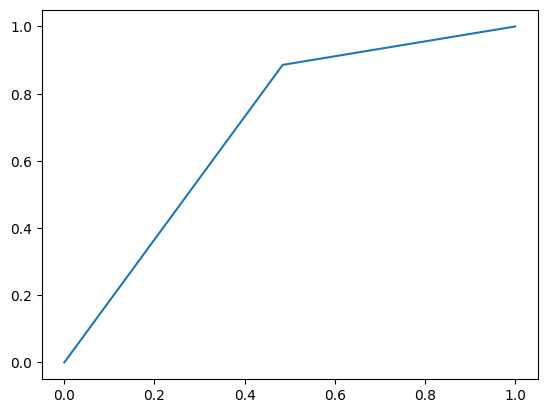

In [24]:
# roc_auc
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
print(roc_auc_score(y_test, y_pred))
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)

Text(50.722222222222214, 0.5, 'Actual')

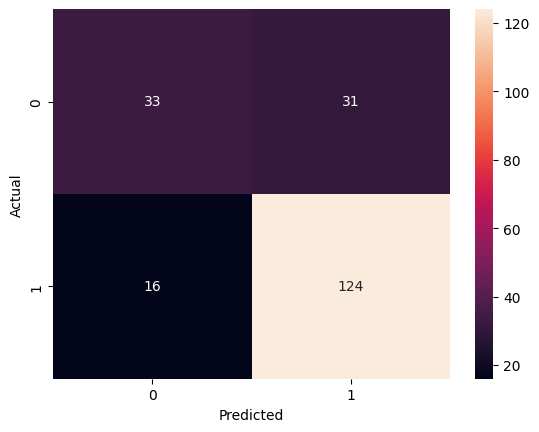

In [25]:
# confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [26]:
print(rf_optimal.best_score_)

-0.43906888962455676


<Axes: >

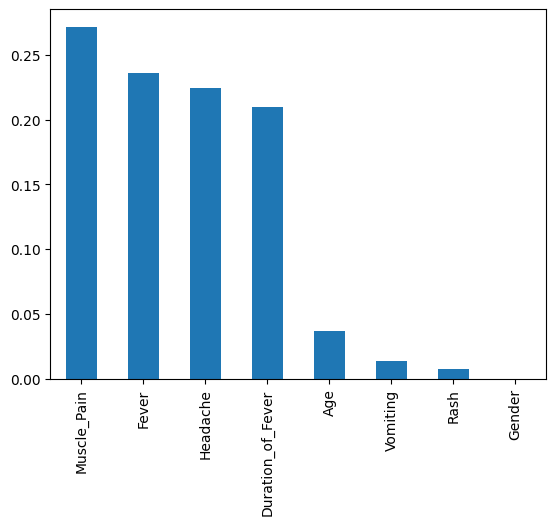

In [27]:
important_feat = pd.Series(rf_optimal.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
important_feat.plot(kind='bar')

## Understand Decision Trees

### Subtask:
Provide a high-level overview of how decision trees work, including concepts like impurity (Gini or entropy), splitting criteria, and stopping conditions, as they are the foundational elements of a Random Forest.


## Understanding Decision Trees

### What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It builds a model in the form of a tree structure, where each internal node represents a test on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label (in classification) or a numerical value (in regression).

### How it Makes Decisions:
*   **Nodes:** Represent a feature or attribute that is used to make a decision.
*   **Branches:** Represent the possible outcomes or values of the feature test.
*   **Leaves:** Represent the final decision or prediction after a sequence of decisions.

The tree starts from a root node and recursively splits the data based on certain conditions, forming a hierarchical structure.

### Key Concepts:

#### Impurity Measures:
Impurity measures quantify how mixed the classes are within a given set of data. The goal of a decision tree is to reduce impurity as much as possible with each split.

*   **Gini Impurity:** This measure calculates the probability of incorrectly classifying a randomly chosen element from the dataset if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all elements belong to a single class (pure node).
    Formula: $G = 1 - \sum_{i=1}^{C} (p_i)^2$

*   **Entropy:** Originating from information theory, entropy measures the randomness or unpredictability in a set of data. A higher entropy indicates a more mixed dataset, while an entropy of 0 indicates a pure dataset.
Formula: $E = - \sum_{i=1}^{C} p_i \log_2(p_i)$

#### Splitting Criteria:
The algorithm selects the best split at each node by evaluating different features and their possible values based on an impurity measure. The split that results in the largest reduction in impurity (or the largest information gain, if using entropy) is chosen.

#### Stopping Conditions:
Decision trees continue to grow until one or more stopping conditions are met. These conditions prevent overfitting and control the complexity of the tree:

*   **Maximum Depth:** The tree stops splitting once a certain maximum number of levels is reached.
*   **Minimum Samples Split:** A node will only be split if it contains a minimum number of samples (e.g., 2, 5, 10). If a node has fewer samples than this threshold, it becomes a leaf node.
*   **Minimum Samples Leaf:** A split is only considered if both resulting child nodes would have at least a minimum number of samples.
*   **Minimum Impurity Decrease:** A split is only performed if it results in a decrease of impurity greater than or equal to a specified threshold.
*   **No Further Information Gain:** If no split can improve the purity of the dataset, the node becomes a leaf.

## Implement Decision Tree Classifier

### Subtask:
Develop a class for a Decision Tree Classifier from scratch, including methods for fitting the tree to data, making predictions, and handling feature splitting based on Gini impurity.


**Reasoning**:
The first step in implementing the Decision Tree Classifier is to define the `Node` class as specified in the instructions. This class will represent a node in the decision tree and will store information about the split (feature index, threshold) or the predicted value if it's a leaf node.



In [28]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        # For leaf node
        self.value = value

In [41]:
print(rf_custom.trees[0].root)

**Reasoning**:
Now that the `Node` class is defined, the next step is to define the `DecisionTree` class with its `__init__` method as specified in the instructions. This method will initialize the `max_depth` and `min_samples_split` parameters, and set the root of the tree to `None`.



In [31]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature_idx = None
        best_threshold = None
        n_samples, n_features = X.shape

        if n_samples <= 1: # Cannot split if no or only one sample
            return None, None

        # If all labels are the same, no split is needed
        if len(np.unique(y)) == 1:
            return None, None

        for feature_idx in range(n_features):
            thresholds = np.unique(X.iloc[:, feature_idx])

            for threshold in thresholds:
                # Split data based on current feature and threshold
                left_indices = X.iloc[:, feature_idx] <= threshold
                right_indices = X.iloc[:, feature_idx] > threshold

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # Calculate weighted Gini impurity for the split
                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)

                weighted_gini = (len(y_left) / n_samples) * gini_left + \
                                (len(y_right) / n_samples) * gini_right

                # Check if this split is better than the current best
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

**Reasoning**:
The next step in implementing the `DecisionTree` class is to add the private recursive method `_grow_tree(X, y, depth)` as specified in the instructions. This method will build the decision tree, handling stopping conditions and storing the majority class for leaf nodes.



In [32]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature_idx = None
        best_threshold = None
        n_samples, n_features = X.shape

        if n_samples <= 1:
            return None, None

        if len(np.unique(y)) == 1:
            return None, None

        for feature_idx in range(n_features):
            thresholds = np.unique(X.iloc[:, feature_idx])

            for threshold in thresholds:
                left_indices = X.iloc[:, feature_idx] <= threshold
                right_indices = X.iloc[:, feature_idx] > threshold

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)

                weighted_gini = (len(y_left) / n_samples) * gini_left + \
                                (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

    def _grow_tree(self, X, y, depth):
        # Base cases for stopping
        if len(np.unique(y)) == 1 or len(y) < self.min_samples_split or (self.max_depth is not None and depth == self.max_depth):
            # Make this a leaf node
            return Node(value=self._most_common_label(y))

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        # If no good split found, make it a leaf node
        if feature_idx is None:
            return Node(value=self._most_common_label(y))

        # Split the data
        left_indices = X.iloc[:, feature_idx] <= threshold
        right_indices = X.iloc[:, feature_idx] > threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        # Recursively build left and right subtrees
        left_subtree = self._grow_tree(X_left, y_left, depth + 1)
        right_subtree = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_idx, threshold, left_subtree, right_subtree)

    def _most_common_label(self, y):
        counts = np.bincount(y.astype(int))
        return np.argmax(counts)

**Reasoning**:
The next step is to implement the `fit(X, y)` method. This method will serve as the entry point for training the decision tree, calling the private `_grow_tree` method to build the tree from the training data.



In [33]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature_idx = None
        best_threshold = None
        n_samples, n_features = X.shape

        if n_samples <= 1:
            return None, None

        if len(np.unique(y)) == 1:
            return None, None

        for feature_idx in range(n_features):
            # Handle potential non-numeric data in thresholds if necessary, though current context suggests numeric.
            thresholds = np.unique(X.iloc[:, feature_idx])

            for threshold in thresholds:
                left_indices = X.iloc[:, feature_idx] <= threshold
                right_indices = X.iloc[:, feature_idx] > threshold

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)

                weighted_gini = (len(y_left) / n_samples) * gini_left + \
                                (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

    def _grow_tree(self, X, y, depth):
        # Base cases for stopping
        if len(np.unique(y)) == 1 or len(y) < self.min_samples_split or (self.max_depth is not None and depth == self.max_depth):
            # Make this a leaf node
            return Node(value=self._most_common_label(y))

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        # If no good split found (e.g., all samples are identical or cannot be split further while reducing impurity)
        if feature_idx is None:
            return Node(value=self._most_common_label(y))

        # Split the data
        left_indices = X.iloc[:, feature_idx] <= threshold
        right_indices = X.iloc[:, feature_idx] > threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        # Recursively build left and right subtrees
        left_subtree = self._grow_tree(X_left, y_left, depth + 1)
        right_subtree = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_idx, threshold, left_subtree, right_subtree)

    def _most_common_label(self, y):
        counts = np.bincount(y.astype(int))
        return np.argmax(counts)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, 0)


**Reasoning**:
The next step is to implement the private recursive method `_predict(x, tree)` as specified in the instructions. This method will traverse the decision tree to make a prediction for a single input sample `x`.



In [34]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature_idx = None
        best_threshold = None
        n_samples, n_features = X.shape

        if n_samples <= 1:
            return None, None

        if len(np.unique(y)) == 1:
            return None, None

        for feature_idx in range(n_features):
            thresholds = np.unique(X.iloc[:, feature_idx])

            for threshold in thresholds:
                left_indices = X.iloc[:, feature_idx] <= threshold
                right_indices = X.iloc[:, feature_idx] > threshold

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)

                weighted_gini = (len(y_left) / n_samples) * gini_left + \
                                (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

    def _grow_tree(self, X, y, depth):
        # Base cases for stopping
        if len(np.unique(y)) == 1 or len(y) < self.min_samples_split or (self.max_depth is not None and depth == self.max_depth):
            # Make this a leaf node
            return Node(value=self._most_common_label(y))

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        # If no good split found (e.g., all samples are identical or cannot be split further while reducing impurity)
        if feature_idx is None:
            return Node(value=self._most_common_label(y))

        # Split the data
        left_indices = X.iloc[:, feature_idx] <= threshold
        right_indices = X.iloc[:, feature_idx] > threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        # Recursively build left and right subtrees
        left_subtree = self._grow_tree(X_left, y_left, depth + 1)
        right_subtree = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_idx, threshold, left_subtree, right_subtree)

    def _most_common_label(self, y):
        counts = np.bincount(y.astype(int))
        return np.argmax(counts)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, 0)

    def _predict(self, x, tree):
        if tree.value is not None:
            return tree.value

        feature_value = x[tree.feature_idx]

        if feature_value <= tree.threshold:
            return self._predict(x, tree.left)
        else:
            return self._predict(x, tree.right)


**Reasoning**:
The final step for the `DecisionTree` class implementation is to add the public `predict(X)` method. This method will apply the private `_predict` method to each sample in the input `X` to return an array of predictions.



In [35]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature_idx = None
        best_threshold = None
        n_samples, n_features = X.shape

        if n_samples <= 1:
            return None, None

        if len(np.unique(y)) == 1:
            return None, None

        for feature_idx in range(n_features):
            thresholds = np.unique(X.iloc[:, feature_idx])

            for threshold in thresholds:
                left_indices = X.iloc[:, feature_idx] <= threshold
                right_indices = X.iloc[:, feature_idx] > threshold

                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)

                weighted_gini = (len(y_left) / n_samples) * gini_left + \
                                (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

    def _grow_tree(self, X, y, depth):
        # Base cases for stopping
        if len(np.unique(y)) == 1 or len(y) < self.min_samples_split or (self.max_depth is not None and depth == self.max_depth):
            # Make this a leaf node
            return Node(value=self._most_common_label(y))

        # Find the best split
        feature_idx, threshold = self._best_split(X, y)

        # If no good split found (e.g., all samples are identical or cannot be split further while reducing impurity)
        if feature_idx is None:
            return Node(value=self._most_common_label(y))

        # Split the data
        left_indices = X.iloc[:, feature_idx] <= threshold
        right_indices = X.iloc[:, feature_idx] > threshold

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        # Recursively build left and right subtrees
        left_subtree = self._grow_tree(X_left, y_left, depth + 1)
        right_subtree = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_idx, threshold, left_subtree, right_subtree)

    def _most_common_label(self, y):
        counts = np.bincount(y.astype(int))
        return np.argmax(counts)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, 0)

    def _predict(self, x, tree):
        if tree.value is not None:
            return tree.value

        feature_value = x[tree.feature_idx]

        if feature_value <= tree.threshold:
            return self._predict(x, tree.left)
        else:
            return self._predict(x, tree.right)

    def predict(self, X):
        return np.array([self._predict(x, self.root) for x in X.values])

## Understanding Bagging (Bootstrap Aggregating)

### Subtask:
Explain the concept of Bagging, which is a core component of Random Forests. This explanation should cover bootstrapping and how predictions from multiple models are aggregated.

### What is Bagging?
Bagging, short for Bootstrap Aggregating, is an ensemble learning technique designed to improve the stability and accuracy of machine learning algorithms. It works by training multiple models on different subsets of the training data and then combining their predictions.

### Key Concepts:

#### 1. Bootstrapping:
Bootstrapping is a sampling technique where `n` samples are drawn *with replacement* from the original dataset of size `N`. This means that each sample has an equal chance of being selected more than once, and some original samples might not be selected at all in a given bootstrap sample. Typically, `n` is equal to `N`.

*   **Impact:** By creating diverse training sets, bootstrapping ensures that each base model (e.g., a Decision Tree) is trained on a slightly different view of the data. This helps reduce the variance of the individual models.

#### 2. Training Multiple Models:
Once the bootstrap samples are generated, an independent base learning algorithm (like a Decision Tree) is trained on each of these samples. Each model learns distinct patterns due to the variations in its training data.

#### 3. Aggregation (Voting/Averaging):
After all base models are trained, their predictions are combined to produce a final prediction. The aggregation method depends on the type of task:

*   **For Classification (as in Random Forests):** The most common aggregation method is **majority voting**. Each base model casts a 'vote' for a particular class, and the class with the most votes becomes the final prediction.

*   **For Regression:** The predictions from individual models are typically **averaged** to get the final output.

### Why Bagging Works:
Bagging is particularly effective at reducing *variance* in models that are prone to overfitting, such as deep decision trees. By averaging or voting on the predictions of many diverse models, the errors and biases of individual models tend to cancel each other out, leading to a more robust and generalized overall model. While it primarily reduces variance, it can also slightly reduce bias if the individual models have high bias due to their instability.

**Reasoning**:
The next step is to introduce the `RandomForestClassifier` class, which will orchestrate the training and prediction of multiple `DecisionTree` instances using bagging and feature randomness. I will start by defining its `__init__` method, which will initialize the ensemble's parameters such as the number of trees, maximum depth, minimum samples for splitting, and the number of features to consider for each split.



**Reasoning**:
The next step is to implement the `fit(X, y)` method for the `RandomForestClassifier` class. This method will be responsible for creating multiple Decision Trees, each trained on a bootstrapped sample of the data and a random subset of features, as per the principles of Random Forests and the instructions.



**Reasoning**:
The next step is to implement the `predict(X)` method for the `RandomForestClassifier` class. This method will aggregate predictions from all individual decision trees using majority voting to produce the final prediction for the ensemble.



In [38]:
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features='sqrt', random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_subsets = []
        if self.random_state:
            np.random.seed(self.random_state)

    def fit(self, X, y):
        n_samples, n_total_features = X.shape
        self.trees = []
        self.feature_subsets = []

        if isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_features_to_sample = int(np.sqrt(n_total_features))
            elif self.max_features == 'log2':
                n_features_to_sample = int(np.log2(n_total_features))
            else:
                raise ValueError(f"Invalid max_features: {self.max_features}")
        elif isinstance(self.max_features, int):
            n_features_to_sample = self.max_features
        else:
            n_features_to_sample = n_total_features # Use all features

        for _ in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X.iloc[indices], y.iloc[indices]

            # Feature bagging (random subset of features)
            feature_indices = np.random.choice(n_total_features, n_features_to_sample, replace=False)
            X_sample_subset = X_sample.iloc[:, feature_indices]

            # Create and train a Decision Tree
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample_subset, y_sample)

            self.trees.append(tree)
            self.feature_subsets.append(feature_indices)

    def predict(self, X):
        # Collect predictions from all trees
        predictions = np.zeros((X.shape[0], self.n_estimators), dtype=int)
        for i, tree in enumerate(self.trees):
            # Ensure X passed to predict is a DataFrame with original column names
            X_subset = X.iloc[:, self.feature_subsets[i]]
            predictions[:, i] = tree.predict(X_subset)

        # Majority voting
        # For each sample, count votes for each class and choose the majority
        final_predictions = []
        for i in range(X.shape[0]):
            votes = predictions[i, :]
            # Handle potential non-integer votes if classes aren't strictly 0, 1 etc.
            # For binary classification (0 or 1), bincount works well
            if len(np.unique(votes)) > 0:
                bincount_result = np.bincount(votes.astype(int))
                final_predictions.append(np.argmax(bincount_result))
            else:
                # If no predictions (shouldn't happen with valid trees), handle gracefully
                final_predictions.append(0) # Default to class 0 or raise error

        return np.array(final_predictions)


**Reasoning**:
With the `RandomForestClassifier` class fully implemented, the final step for this subtask is to test and evaluate its performance using the preprocessed data. This involves instantiating the classifier, training it on the training data, and then making predictions on the test set to calculate standard evaluation metrics like accuracy, classification report, and ROC AUC score.



In [39]:
rf_custom = RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=5, max_features='sqrt', random_state=42)
rf_custom.fit(X_train, y_train)
y_pred_custom = rf_custom.predict(X_test)

print(f"Custom Random Forest Accuracy: {accuracy_score(y_test, y_pred_custom)}")
print(f"Custom Random Forest Classification Report:\n{classification_report(y_test, y_pred_custom)}")
print(f"Custom Random Forest ROC AUC Score: {roc_auc_score(y_test, y_pred_custom)}")

Custom Random Forest Accuracy: 0.7450980392156863
Custom Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.23      0.37        64
           1       0.74      0.98      0.84       140

    accuracy                           0.75       204
   macro avg       0.78      0.61      0.60       204
weighted avg       0.77      0.75      0.69       204

Custom Random Forest ROC AUC Score: 0.6064732142857143


### Custom Random Forest Evaluation Visualizations

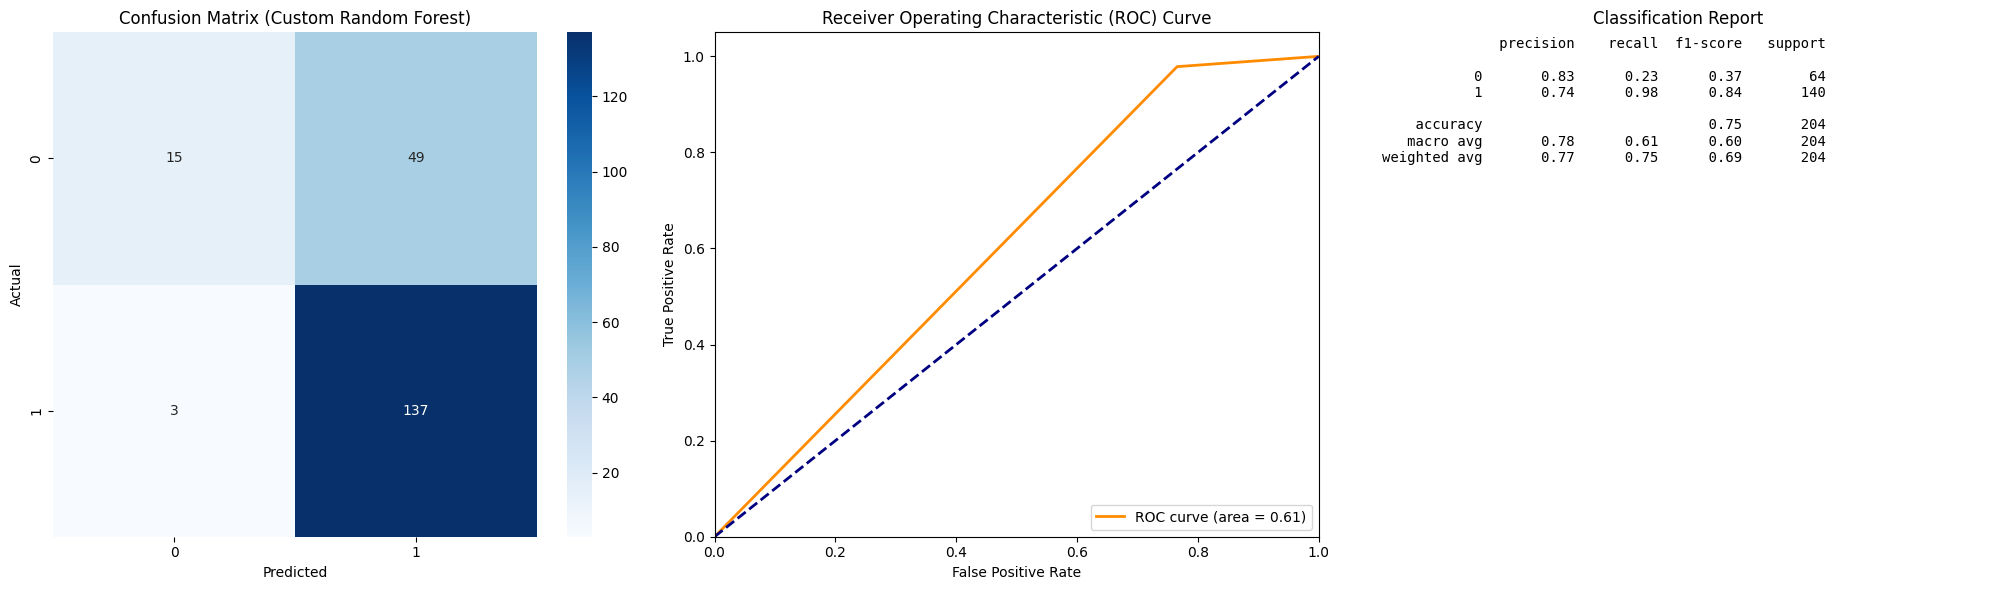

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# 1. Create a figure with a suitable size and a grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 2. First subplot: Confusion Matrix
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Custom Random Forest)')

# 3. Second subplot: ROC Curve
roc_auc = roc_auc_score(y_test, y_pred_custom)
fpr_custom, tpr_custom, _ = roc_curve(y_test, y_pred_custom)
axes[1].plot(fpr_custom, tpr_custom, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

# 4. Third subplot: Classification Report
report = classification_report(y_test, y_pred_custom)
axes[2].text(0.01, 0.99, report, {'fontsize': 10}, fontfamily='monospace', va='top')
axes[2].axis('off') # Turn off axes for the text subplot
axes[2].set_title('Classification Report')

# 5. Adjust layout and display the combined figure
plt.tight_layout()
plt.show()